## Section 1.4: Principle Component Analysis
**Topics:** Singular value Decomposition, Low-Rank Matrix approximations, Principal Component Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/16RzzEiCPrGcUMsBO1P097gLKdnCcrkMB?usp=sharing)

In [32]:
# Import Necessary Packages
import numpy as np
import matplotlib.pyplot as plt
# Formatting and Spacing:
np.set_printoptions(formatter={'int': str})

## Section 1.4.1: Singular Value Decomposition
Singular Value Decomposition (SVD) decomposes a matrix A into three subcomponents to analyze parts of matrix A. In equation form, A = UσVᵗ, where U and V are orthogonal matrices representing directions, and σ is a diagonal matrix with singular values measuring the weight of each direction.

In our example, we use a 3x3 randomized A matrix, using this to find matrix U, σ, and Vᵀ. From there, we reconstruct A to show SVD. We can also graphically represent the SVD here.

In [35]:
# Print out Matrix A, a andomized 3x3 matrix with element integer values between 1 and 100.
A = np.random.randint(1, 100, size=(3, 3));

# SVD Matrix: Shows factors U, Sigma, and Vt.
U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)
reconstruct_A = U @ Sigma @ Vt

# Print out values and shapes of U, Sigma, and transpose of V.
print("Matrix A = \n", A)
print("Singular Values = \n", s)
print("Matrix U = \n", U, "\nSigma =\n", Sigma, "\nTranspose Matrix of V ww=\n", Vt)
print("Matrix U Shape =", U.shape, ", Matrix Sigma shape =", Sigma.shape, "Vt shape =", Vt.shape)

# Reconstruct Matrix A, and calculate reconstruct validation and accuracy.
print("Reconstructed Matrix A =\n", reconstruct_A)
print("Reconstruction error ||A - UσVᵗ||_F =", np.linalg.norm(A - reconstruct_A, ord="fro"))
print("Compared to A, is the reconstruction accurate here? = ", np.allclose(A, reconstruct_A))

Matrix A = 
 [[29 12 76]
 [98 93 37]
 [25 72 64]]
Singular Values = 
 [175.50442313  65.92045316  33.77412198]
Matrix U = 
 [[-0.35884738  0.74960389 -0.55616775]
 [-0.76624425 -0.57683704 -0.28307028]
 [-0.53300874  0.32458131  0.78137613]] 
Sigma =
 [[175.50442313   0.           0.        ]
 [  0.          65.92045316   0.        ]
 [  0.           0.          33.77412198]] 
Transpose Matrix of V ww=
 [[-0.56308398 -0.64923442 -0.51130334]
 [-0.40468449 -0.3228246   0.8555786 ]
 [-0.72053237  0.68867913 -0.08095774]]
Matrix U Shape = (3, 3) , Matrix Sigma shape = (3, 3) Vt shape = (3, 3)
Reconstructed Matrix A =
 [[29. 12. 76.]
 [98. 93. 37.]
 [25. 72. 64.]]
Reconstruction error ||A - UσVᵗ||_F = 1.0474482073025775e-13
Compared to A, is the reconstruction accurate here? =  True


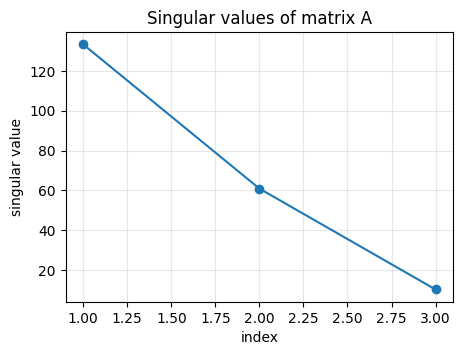

In [24]:
# We plot the singular values of matrix A, creating a linear correlation between singular value and index.
# 1. X-axis: index.
# 2. Y-axis: Singular Value

plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(s) + 1), s, marker="o")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of matrix A")
plt.grid(True, alpha=0.3)
plt.show()

## Section 1.4.2. Low-Rank Matrix Approximations

Low-rank matrix approximations replace bigger matrices with smaller matrices to find noticable patterns in matrices, like Matrix A. Here, we demonstrate this with a rank-k approximation, using that to find the frontibus error and matrix rank.

Additionally, we can graph the low-rank approximation error, using ||A - Aₖ||_F as the x-axis and y-axis.

Rank-1 approximation:
[[35.46263577 40.88833063 32.20152718]
 [75.7231133  87.30856085 68.75969137]
 [52.6739109  60.73288796 47.83007063]]
Frobenius error = 74.06886971439559
matrix rank = 1

Rank-2 approximation:
[[15.46546419 24.93620197 74.47928362]
 [91.11138626 99.58408238 36.22600761]
 [44.01506031 53.82555618 66.13649836]]
Frobenius error = 33.774121983521454
matrix rank = 2

Rank-3 approximation:
[[29. 12. 76.]
 [98. 93. 37.]
 [25. 72. 64.]]
Frobenius error = 1.0474482073025775e-13
matrix rank = 3



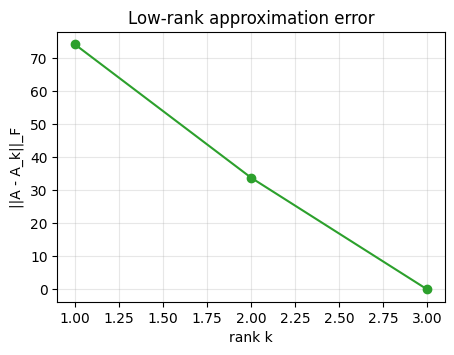

In [36]:
# Approximation Rank-k Error:
def approximation_rank_k(U, s, Vt, k):
  return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

# Rank-k approximation, Find frobenius and matrix rank.
errors_from_approx_rank_k = []
for k in range(1, len(s) + 1):
  A_k = approximation_rank_k(U, s, Vt, k)
  error = np.linalg.norm(A - A_k, ord="fro")
  errors_from_approx_rank_k.append(error)
  print(f"Rank-{k} approximation:")
  print(A_k)
  print("Frobenius error =", error)
  print("matrix rank =", np.linalg.matrix_rank(A_k))
  print()
# Plot the ||A - A_k||_F versus the rank k.
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(errors_from_approx_rank_k) + 1), errors_from_approx_rank_k, marker="o", color="tab:green")
plt.xlabel("rank k")
plt.ylabel("||A - A_k||_F")
plt.title("Low-rank approximation error")
plt.grid(True, alpha=0.3)
plt.show()


## Section 1.4.3: Principle Component Analysis


Principle Component Analysis (PCA) uses the sample mean and the covariant matrix to calculate the k-value, where k is the principal component that maximizes the objective function.
There are two important eigenvectors here in PCA.



In this example, we take 100 data samples and 10 features for PCA analysis.
Using these samples, we can calculate the PCA parameters using SVD to find directions of maximum variation in centered data.  

In [53]:
# Use 100 numerical samples with 10 numerical features.
num_samples = 100
num_features = 10

# Base Data for First 2 Principal Components.
pc1_base = np.random.rand(num_samples) * 10
pc2_base = np.random.rand(num_samples) * 5

# Combine Principal Components
X = np.zeros((num_samples, num_features))
for i in range(num_features):
    X[:, i] = 0.6 * pc1_base + 0.4 * pc2_base * ((-1)**i) + np.random.randn(num_samples) * 2

# Calculate mean, centered x-value, PCA parameters, variance and ratio.
mean = X.mean(axis=0)
X_centered = X - mean
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)
scores = X_centered @ Vt_pca.T
explained_variance = (s_pca**2) / (len(X) - 1)
explained_ratio = explained_variance / explained_variance.sum()
# Print out feature means, PCA parameters, variance parameters, and first 3 PCA Scores.
print("Feature means =", mean)
print("principal directions as rows of Vt =")
print(f"{Vt_pca}")
print(f"Singular values =\n{s_pca}")
print(f"Explained variance =\n{explained_variance}")
print(f"Explained variance ratio =\n{explained_ratio}")
print("First three PCA scores =")
print(scores[:3])

Feature means = [4.0570268  1.94936383 4.35574259 2.59638119 4.44143449 2.10894308
 4.25517466 2.2485193  4.03418086 2.39446992]
principal directions as rows of Vt =
[[-0.32713238 -0.30255658 -0.3398131  -0.28598588 -0.33187584 -0.33112549
  -0.29319682 -0.38697616 -0.26405312 -0.2809954 ]
 [-0.312088    0.28491615 -0.36660897  0.49254129 -0.25972006  0.27428221
  -0.3746704   0.3556545  -0.17939211  0.05186527]
 [-0.36981288 -0.14842337 -0.17984644 -0.59892383 -0.07082835  0.4193331
   0.31982741  0.38885022  0.01351486  0.12498326]
 [-0.11243485  0.12382659 -0.36004272  0.30005743  0.02162428  0.26718607
   0.60104226 -0.4366025   0.10946477 -0.34153781]
 [-0.06010295  0.74848758 -0.1486022  -0.41315917  0.13682839 -0.03391916
  -0.25910866 -0.20897287  0.33538665 -0.01439395]
 [ 0.06466662 -0.26256673  0.27455828  0.00261416 -0.30544929  0.56936047
  -0.36473891 -0.2416552   0.46534967 -0.16135434]
 [-0.52992938 -0.14912021  0.07060141  0.17512727  0.25331685 -0.02250208
  -0.036939

Here, we center PCA directions to represent the two feature areas using a graphical representation.

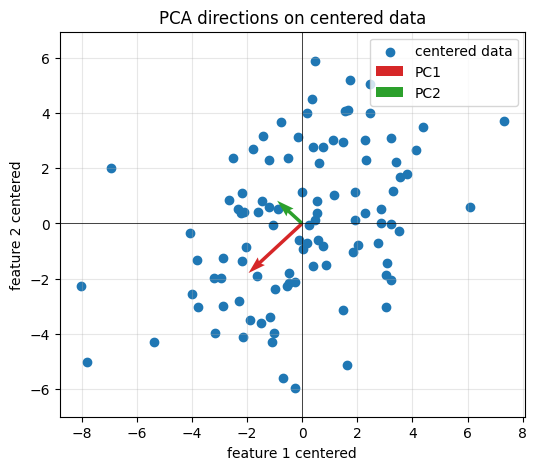

In [54]:
# Plot the PCA1 and PCA2 values
origin = np.zeros(2)
pc1 = Vt_pca[0] * s_pca[0] / np.sqrt(len(X) - 1)
pc2 = Vt_pca[1] * s_pca[1] / np.sqrt(len(X) - 1)
# Set the figure size, scatterplot, x-label and y-label, and indicate which parts are PC1 and PC2.
plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color="tab:blue", label="centered data")
plt.quiver(*origin, pc1[0], pc1[1], angles="xy", scale_units="xy", scale=1, color="tab:red", label="PC1")
plt.quiver(*origin, pc2[0], pc2[1], angles="xy", scale_units="xy", scale=1, color="tab:green", label="PC2")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("feature 1 centered")
plt.ylabel("feature 2 centered")
plt.title("PCA directions on centered data")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()